# **PREPROCESSING AND EDA ON STRATIFIED SPLITTED DATA**



*   EDA on Datasets

*   Class Balancing
*   Image Transformation



In [18]:
# imports

import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
from PIL import Image
from torchvision import transforms

from torch.utils.data import Dataset, DataLoader

In [9]:
# ===== PATH SETUP =========

PROJECT_ROOT = "/content/drive/MyDrive/cassava_leaf_disease_classification"
PROCESSED_DATA_DIR = os.path.join(PROJECT_ROOT, "data/processed")
OUTPUT_IMG_DIR = os.path.join(PROJECT_ROOT, "output/image")

# Ensure the output directory exists
os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)


train_csv = os.path.join(PROCESSED_DATA_DIR, "train_split.csv")
val_csv = os.path.join(PROCESSED_DATA_DIR, "val_split.csv")
test_csv = os.path.join(PROCESSED_DATA_DIR, "test_split.csv")

In [23]:
# ======= LOAD TRAINING SPLIT =======

train_csv_path = os.path.join(PROCESSED_DATA_DIR, "train_split.csv")
train_df = pd.read_csv(train_csv_path)

# Label mapping for clean readability on the chart
label_map = {
    0: "Cassava Bacterial Blight (CBB)",
    1: "Cassava Brown Streak Disease (CBSD)",
    2: "Cassava Green Mite (CGM)",
    3: "Cassava Mosaic Disease (CMD)",
    4: "Healthy"
}

# Calculate class counts and map names
class_counts = train_df['label'].value_counts().sort_index()
class_names = [label_map[idx] for idx in class_counts.index]

class_counts

,count
label,
0,761
1,1532
2,1670
3,9210
4,1804


Training class distribution chart successfully saved to: /content/drive/MyDrive/cassava_leaf_disease_classification/output/image/train_class_distribution.png


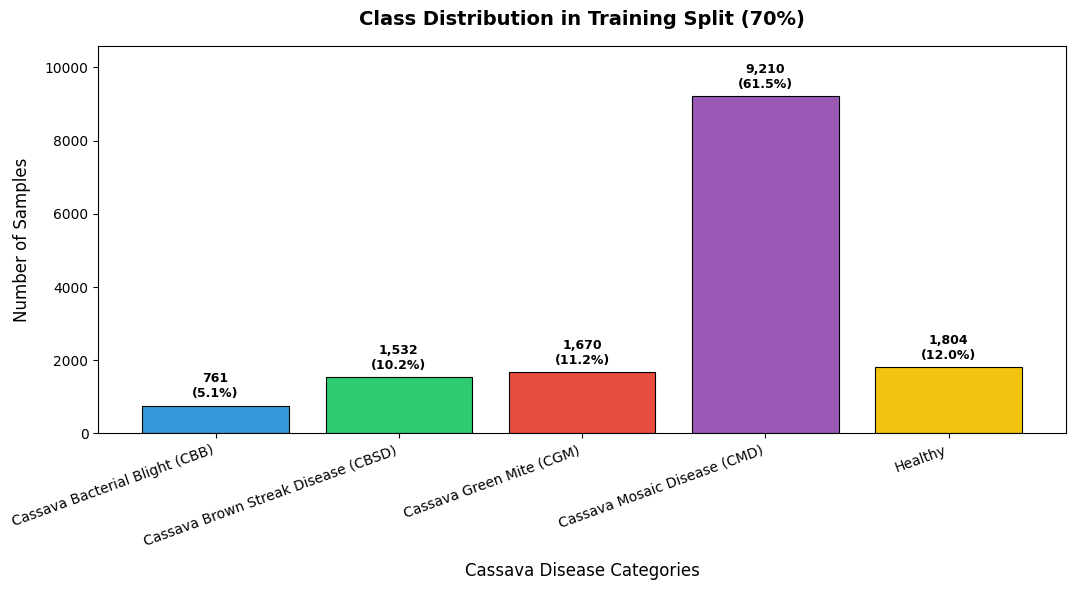

In [7]:
# ======= PLOTTING DISTRIBUTION =======
plt.figure(figsize=(11, 6))
bars = plt.bar(
    class_names,
    class_counts.values,
    color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f1c40f'],
    edgecolor='black',
    linewidth=0.8
)

plt.title("Class Distribution in Training Split (70%)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cassava Disease Categories", fontsize=12, labelpad=10)
plt.ylabel("Number of Samples", fontsize=12, labelpad=10)
plt.xticks(rotation=20, ha='right', fontsize=10)

# Print explicit totals and percentages above each bar for analytical tracking
total_train = len(train_df)
for bar in bars:
    height = bar.get_height()
    percentage = (height / total_train) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        height + (total_train * 0.01),
        f'{height:,}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='semibold'
    )

plt.ylim(0, max(class_counts.values) * 1.15) # Leave headroom for text labels
plt.tight_layout()

# ======= SAVE AND SHOW =======
output_plot_path = os.path.join(OUTPUT_IMG_DIR, "train_class_distribution.png")
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
print(f"Training class distribution chart successfully saved to: {output_plot_path}")

plt.show()

Validation distribution chart saved to: /content/drive/MyDrive/cassava_leaf_disease_classification/output/image/val_class_distribution.png


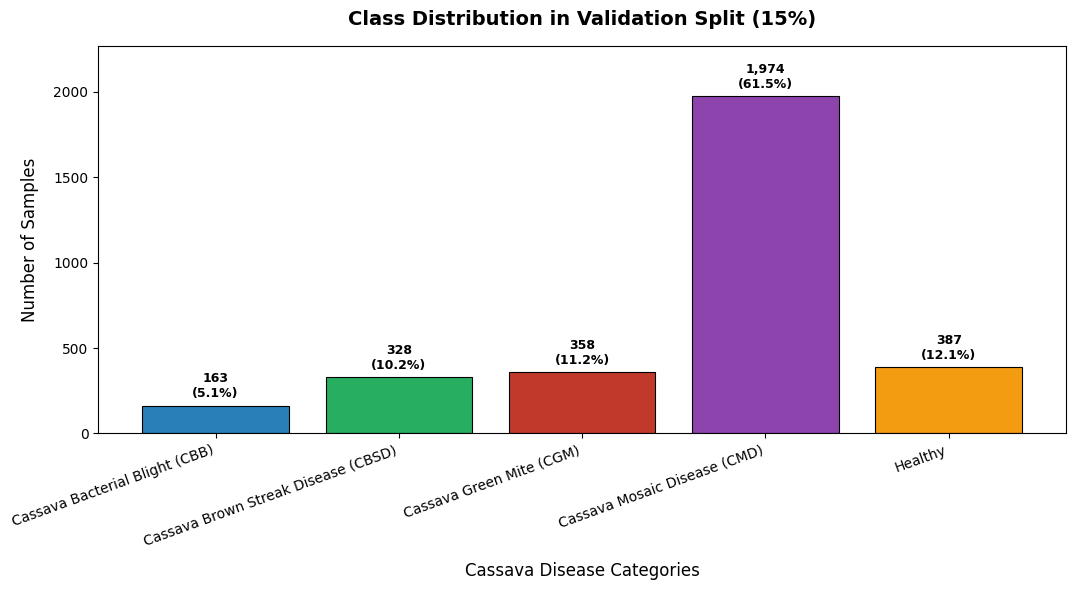

In [24]:
# =======  VALIDATION SPLIT DISTRIBUTION =======


val_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "val_split.csv"))
val_counts = val_df['label'].value_counts().sort_index()
val_names = [label_map[idx] for idx in val_counts.index]

plt.figure(figsize=(11, 6))
bars_val = plt.bar(
    val_names,
    val_counts.values,
    color=['#2980b9', '#27ae60', '#c0392b', '#8e44ad', '#f39c12'],
    edgecolor='black',
    linewidth=0.8
)

plt.title("Class Distribution in Validation Split (15%)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cassava Disease Categories", fontsize=12, labelpad=10)
plt.ylabel("Number of Samples", fontsize=12, labelpad=10)
plt.xticks(rotation=20, ha='right', fontsize=10)

total_val = len(val_df)
for bar in bars_val:
    height = bar.get_height()
    percentage = (height / total_val) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        height + (total_val * 0.01),
        f'{height:,}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='semibold'
    )

plt.ylim(0, max(val_counts.values) * 1.15)
plt.tight_layout()

val_plot_path = os.path.join(OUTPUT_IMG_DIR, "val_class_distribution.png")
plt.savefig(val_plot_path, dpi=300, bbox_inches='tight')
print(f"Validation distribution chart saved to: {val_plot_path}")
plt.show()

Test distribution chart saved to: /content/drive/MyDrive/cassava_leaf_disease_classification/output/image/test_class_distribution.png


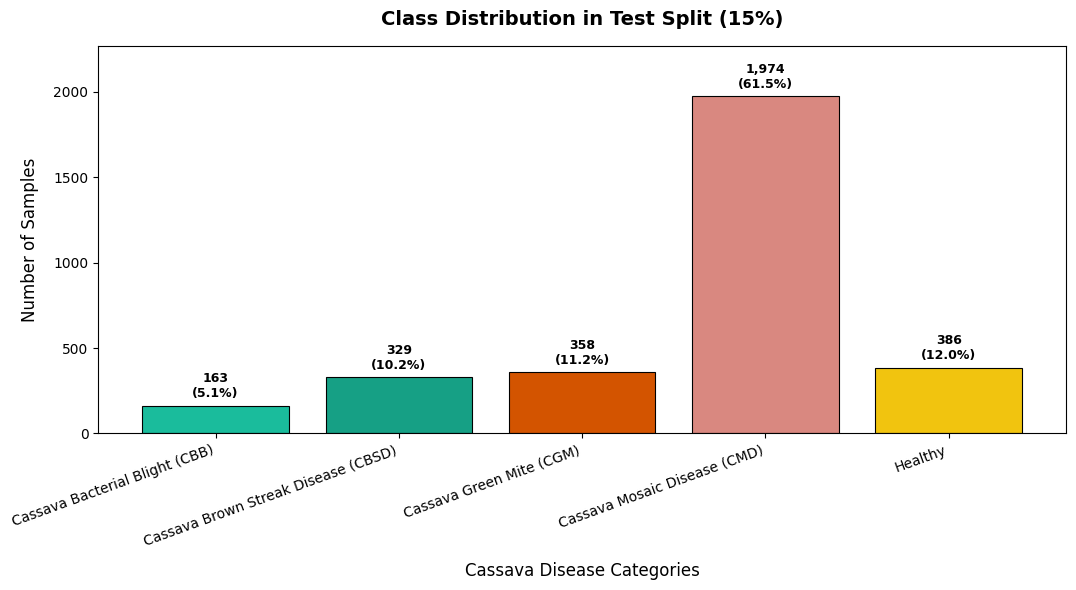

In [9]:
# ======= TEST SPLIT DISTRIBUTION =======


test_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "test_split.csv"))
test_counts = test_df['label'].value_counts().sort_index()
test_names = [label_map[idx] for idx in test_counts.index]

plt.figure(figsize=(11, 6))
bars_test = plt.bar(
    test_names,
    test_counts.values,
    color=['#1abc9c', '#16a085', '#d35400', '#d98880', '#f1c40f'],
    edgecolor='black',
    linewidth=0.8
)

plt.title("Class Distribution in Test Split (15%)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cassava Disease Categories", fontsize=12, labelpad=10)
plt.ylabel("Number of Samples", fontsize=12, labelpad=10)
plt.xticks(rotation=20, ha='right', fontsize=10)

total_test = len(test_df)
for bar in bars_test:
    height = bar.get_height()
    percentage = (height / total_test) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        height + (total_test * 0.01),
        f'{height:,}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='semibold'
    )

plt.ylim(0, max(test_counts.values) * 1.15)
plt.tight_layout()

test_plot_path = os.path.join(OUTPUT_IMG_DIR, "test_class_distribution.png")
plt.savefig(test_plot_path, dpi=300, bbox_inches='tight')
print(f"Test distribution chart saved to: {test_plot_path}")
plt.show()

# **IMAGE DATA TRANSFORMATION**



*   Transformation Pipeline
*   Dataset creation and DataLoader



In [11]:
# ======= WITHOUT AUGMENTATION ========


# ImageNet Normalization Constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training Transformation Pipeline
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


# Validation & Test Transformation Pipeline
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])



print("Image transformation pipelines defined successfully!")
print(f"Training transforms: {train_transforms}")
print(f"Val/Test transforms: {val_test_transforms}")

Image transformation pipelines defined successfully!
Training transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Val/Test transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [5]:
class CassavaDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        """
        Custom Dataset for Cassava Leaf Disease Classification.
        Args:
            csv_path (str): Path to the split CSV manifest (train, val, or test).
            transform (callable, optional): Optional transform to be applied on a sample image.
        """
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Fetch the specific row
        row = self.df.iloc[idx]
        img_path = row['image_path']
        label = int(row['label'])

        # Load image via PIL and ensure 3-channel RGB format
        image = Image.open(img_path).convert('RGB')

        # Apply transformation pipeline if provided
        if self.transform:
            image = self.transform(image)

        # Return the processed image tensor and its integer label
        return image, torch.tensor(label, dtype=torch.long)

In [12]:
# ======= INSTANTIATE DATASETS =======
train_dataset = CassavaDataset(csv_path=train_csv, transform=train_transforms)
val_dataset = CassavaDataset(csv_path=val_csv, transform=val_test_transforms)
test_dataset = CassavaDataset(csv_path=test_csv, transform=val_test_transforms)

print(f"Train Dataset instances: {len(train_dataset)}")
print(f"Validation Dataset instances: {len(val_dataset)}")
print(f"Test Dataset instances: {len(test_dataset)}")

Train Dataset instances: 14977
Validation Dataset instances: 3210
Test Dataset instances: 3210


In [16]:
# ======= 2. CONFIGURE DATALOADERS =======
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # Shuffle training data every epoch
    num_workers=2,         # Multi-process data loading
    pin_memory=True        # Speeds up host-to-GPU tensor transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataLoaders successfully configured!")
print(f"Total training batches per epoch: {len(train_loader)}")
print(f"Total validation batches per epoch: {len(val_loader)}")


DataLoaders successfully configured!
Total training batches per epoch: 469
Total validation batches per epoch: 101


In [20]:
# Fetch a single batch from the train_loader
images, labels = next(iter(train_loader))

print(f"Batch image tensor shape: {images.shape}")
print(f"Batch label tensor shape: {labels.shape}")

Batch image tensor shape: torch.Size([32, 3, 224, 224])
Batch label tensor shape: torch.Size([32])


Transformed image sample successfully saved to: /content/drive/MyDrive/cassava_leaf_disease_classification/output/image/transformed_sample_tensor.png


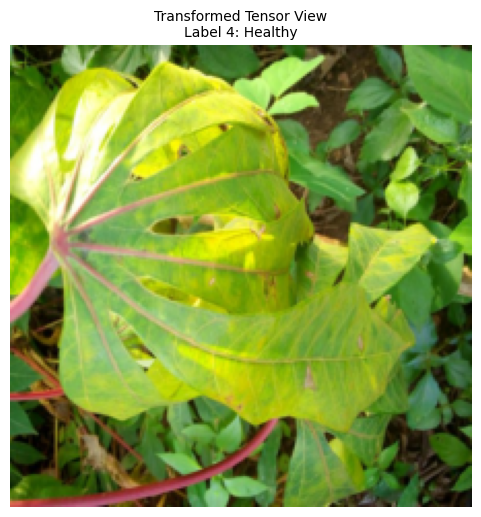

In [26]:
# ======= VISUALIZE TRANSFORMED IMAGES ====



# Grab a batch from your train_loader
images, labels = next(iter(train_loader))

# Pick the first image and label in the batch
img_tensor = images[0]
label_idx = labels[0].item()

# Define the ImageNet Mean and Std used in your transforms
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Denormalize: reverse the normalization formula (pixel = (tensor * std) + mean)
img_denorm = img_tensor * std + mean

# Clamp values safely between 0.0 and 1.0 for display
img_denorm = torch.clamp(img_denorm, 0, 1)

# Permute dimensions from PyTorch (C, H, W) to Matplotlib format (H, W, C)
img_np = img_denorm.permute(1, 2, 0).numpy()


plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.title(f"Transformed Tensor View\nLabel {label_idx}: {label_map.get(label_idx)}", fontsize=10)
plt.axis('off')



# ======= SAVE AND SHOW =======
output_file_path = os.path.join(OUTPUT_IMG_DIR, "transformed_sample_tensor.png")
plt.savefig(output_file_path, dpi=300, bbox_inches='tight')
print(f"Transformed image sample successfully saved to: {output_file_path}")

plt.show()